In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Install and Import Dependencies**

In [2]:
import os                             # make it easier to navigate and traverse through different file systems
import cv2                            # needed to pre-process and load up our videos
import tensorflow as tf               # primary machine learning framework
import numpy as np                    # pre-process any arrays
from typing import List               #
from matplotlib import pyplot as plt  # render the pre-process or post process output
import imageio                        # it like a one-liner which allows you to convert a numpy array to a gif.

In [3]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
# checks if a GPU is available, and if it is, it configures TensorFlow to grow GPU memory usage gradually as needed instead of grabbing all memory at once — which helps prevent memory-related errors in shared environments like Google Colab.

physical_devices = tf.config.list_physical_devices('GPU')
try:
  tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
  pass

# **Build Data Loading Functions**

In [5]:
import gdown # help to download the dataset

In [6]:
# Download the data

url = 'https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL'
output = 'data.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('data.zip')

Downloading...
From (original): https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL
From (redirected): https://drive.google.com/uc?id=1YlvpDLix3S-U8fd-gqRwPcWXAXm8JwjL&confirm=t&uuid=3a36052b-ae92-4865-b24a-0e91c17dc9ff
To: /content/data.zip
100%|██████████| 423M/423M [00:02<00:00, 149MB/s]


['data/',
 'data/alignments/',
 'data/alignments/s1/',
 'data/alignments/s1/bbaf2n.align',
 'data/alignments/s1/bbaf3s.align',
 'data/alignments/s1/bbaf4p.align',
 'data/alignments/s1/bbaf5a.align',
 'data/alignments/s1/bbal6n.align',
 'data/alignments/s1/bbal7s.align',
 'data/alignments/s1/bbal8p.align',
 'data/alignments/s1/bbal9a.align',
 'data/alignments/s1/bbas1s.align',
 'data/alignments/s1/bbas2p.align',
 'data/alignments/s1/bbas3a.align',
 'data/alignments/s1/bbaszn.align',
 'data/alignments/s1/bbaz4n.align',
 'data/alignments/s1/bbaz5s.align',
 'data/alignments/s1/bbaz6p.align',
 'data/alignments/s1/bbaz7a.align',
 'data/alignments/s1/bbbf6n.align',
 'data/alignments/s1/bbbf7s.align',
 'data/alignments/s1/bbbf8p.align',
 'data/alignments/s1/bbbf9a.align',
 'data/alignments/s1/bbbm1s.align',
 'data/alignments/s1/bbbm2p.align',
 'data/alignments/s1/bbbm3a.align',
 'data/alignments/s1/bbbmzn.align',
 'data/alignments/s1/bbbs4n.align',
 'data/alignments/s1/bbbs5s.align',
 'data/al

In [7]:
# Data Loading Function

def load_video(path:str) -> List[float]:
  cap = cv2.VideoCapture(path) # video capturing instance
  frames = []
  for _ in range(int(cap.get(cv2.CAP_PROP_FRAME_COUNT))):
    ret, frame = cap.read()
    if not ret:  # Check if frame was read successfully
        continue  # Skip to the next frame if reading failed
    if len(frame.shape) == 3 and frame.shape[2] == 3: # Check if the frame is color (3 channels)
        frame = tf.image.rgb_to_grayscale(frame) # converting RGB to Grayscale
    # If the frame is already grayscale (1 channel), no conversion is needed.
    frames.append(frame[190:236,80:220,:])  # frame[190:236,80:220,:] isolating mouth regin
  cap.release()

  # Normalize the frames
  if not frames: # Handle case where no frames were successfully loaded
      return tf.constant([], dtype=tf.float32)
  frames_tensor = tf.cast(frames, tf.float32)
  mean = tf.math.reduce_mean(frames_tensor)
  std = tf.math.reduce_std(frames_tensor)
  return (frames_tensor - mean) / std

In [8]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "] # character we might expect to encounter

In [9]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="") # from keras labrary ctc ASR
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z'), np.str_("'"), np.str_('?'), np.str_('!'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_(' ')] (size =40)


In [10]:
def load_alignments(path:str) -> List[str]:

    # Open the alignment file
    with open(path, 'r') as f:
        lines = f.readlines() # read all lines from the file
    tokens = []
    for line in lines: # loop through each line
        line = line.split() # split the line by white space
        if line[2] != 'sil':
            tokens = [*tokens,' ',line[2]]
    return char_to_num(tf.reshape(tf.strings.unicode_split(tokens, input_encoding='UTF-8'), (-1)))[1:]

In [11]:
def load_data(path: str):

    path = bytes.decode(path.numpy()) # path.numpy() = converts it to a byte string, bytes.decode= turns it into regular python string
    # print("Video path:", path)  # Debug

    path = path.replace("\\", "/")
    file_name = os.path.splitext(os.path.basename(path))[0]
    # print("File name:", file_name)

    # construct full paths to video and and alignment file
    video_path = os.path.join('data', 's1', f'{file_name}.mpg')
    alignment_path = os.path.join('data', 'alignments', 's1', f'{file_name}.align')

    if not os.path.exists(alignment_path):
        raise FileNotFoundError(f"Missing alignment file: {alignment_path}")

    # load video frames & alignment labels
    frames = load_video(video_path)
    alignments = load_alignments(alignment_path)

    # return both video data and label data for training.
    return frames, alignments

In [12]:
test_path = '.\\data\\s1\\bbal6n.mpg'

In [13]:
tf.convert_to_tensor(test_path).numpy().decode('utf-8').split('\\')[-1].split('.')[0]

'bbal6n'

In [14]:
frames, alignments = load_data(tf.convert_to_tensor(test_path))

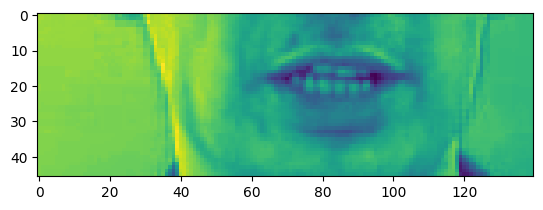

In [15]:
plt.imshow(frames[40])

In [16]:
tf.strings.reduce_join([bytes.decode(x) for x in num_to_char(alignments.numpy()).numpy()])

<tf.Tensor: shape=(), dtype=string, numpy=b'bin blue at l six now'>

In [17]:
def mappable_function(path:str) ->List[str]:
    result = tf.py_function(load_data, [path], (tf.float32, tf.int64))
    return result

# 2. **Creat Data Pipeline**

In [18]:
data = tf.data.Dataset.list_files('./data/s1/*.mpg') # finds all .mpg video files in the folder ./data/s1/.
data = data.shuffle(500, reshuffle_each_iteration=False) # Mixes up the order of the video files randomly.
data = data.map(mappable_function) # mappable_function() to:Load the video frames Load the spoken text labels
data = data.padded_batch(2, padded_shapes=([75, 46, 140, 1],[40])) # Batch the data
data = data.prefetch(tf.data.AUTOTUNE) # While the model is training on batch N, it prepares batch N+1 in the background. This speeds up training by overlapping data loading and model training.

# Added for split
train = data.take(450)
test = data.skip(450)

In [19]:
frames, alignments = data.as_numpy_iterator().next()

In [20]:
len(frames)

2

In [21]:
sample = data.as_numpy_iterator()

In [22]:
val = sample.next(); val[0]

array([[[[[ 1.1449682 ],
          [ 1.3048387 ],
          [ 1.1449682 ],
          ...,
          [ 0.30564833],
          [ 0.2656807 ],
          [ 0.2656807 ]],

         [[ 0.98509777],
          [ 1.2249035 ],
          [ 1.1050006 ],
          ...,
          [ 0.30564833],
          [ 0.2656807 ],
          [ 0.2656807 ]],

         [[ 0.74529207],
          [ 0.8651949 ],
          [ 0.78525966],
          ...,
          [ 0.30564833],
          [ 0.2656807 ],
          [ 0.2656807 ]],

         ...,

         [[ 1.1849358 ],
          [ 1.1849358 ],
          [ 1.1449682 ],
          ...,
          [ 0.02587503],
          [ 0.02587503],
          [ 0.02587503]],

         [[ 1.065033  ],
          [ 1.065033  ],
          [ 1.1050006 ],
          ...,
          [ 0.02587503],
          [ 0.02587503],
          [ 0.02587503]],

         [[ 1.065033  ],
          [ 1.065033  ],
          [ 1.1050006 ],
          ...,
          [ 0.02587503],
          [ 0.02587503],
          

In [23]:
import numpy as np
import imageio.v2 as imageio   # use v2 API to silence deprecation warnings

# `frames_tf` is the tensor you want to visualise, shape (T, H, W, 1)
frames_tf = val[0][0]                     # (75, H, W, 1) float32
frames_np = frames_tf             # → NumPy array

# Undo the z‑score normalisation:  0‑255 uint8, then drop the last dim
frames_uint8 = np.clip((frames_np * 255), 0, 255).astype(np.uint8)
frames_uint8 = frames_uint8.squeeze(-1)   # (T, H, W)

# `imageio.mimsave` needs a *sequence* of (H,W) or (H,W,3) arrays
imageio.mimsave("./animation.gif", list(frames_uint8), fps=10)

In [24]:
frames_rgb = np.repeat(frames_uint8[..., None], 3, axis=-1)  # (T,H,W,3)
imageio.mimsave("./animation.gif", list(frames_rgb), fps=10)

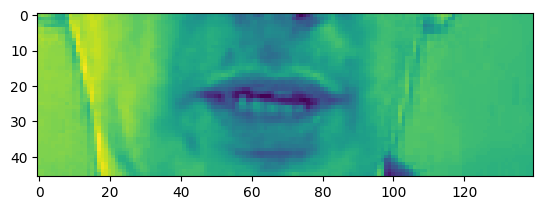

In [25]:
# 0:videos, 0: 1st video out of the batch,  0: return the first frame in the video
plt.imshow(val[0][0][35])

In [26]:
tf.strings.reduce_join([num_to_char(word) for word in val[1][0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'place white by q seven again'>

# **3. Design Deep Neural Network**

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

In [28]:
data.as_numpy_iterator().next()[0][0].shape

(75, 46, 140, 1)

In [29]:
model = Sequential()

# Con3D Block 1
model.add(Conv3D(128, 3, input_shape=(75,46,140,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

# Con3D Block 2
model.add(Conv3D(256, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

# Con3D Block 3
model.add(Conv3D(75, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))

# Flatten Time dimension
model.add(TimeDistributed(Flatten()))


# LSTM Layers
model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

# Output
model.add(Dense(char_to_num.vocabulary_size()+1, kernel_initializer='he_normal', activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 75, 46, 140,    │         3,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 75, 46, 140,    │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 75, 23, 70,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 75, 23, 70,     │       884,992 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 23, 70,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 75, 11, 35,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 75, 11, 35, 75) │       518,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 75, 11, 35, 75) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 75, 5, 17, 75)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 75, 6375)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 75, 256)        │     6,660,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 75, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 75, 41)         │        10,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,471,924 (32.32 MB)

 Trainable params: 8,471,924 (32.32 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
yhat = model.predict(val[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [32]:
tf.strings.reduce_join([num_to_char(x) for x in tf.argmax(yhat[0],axis=1)])

<tf.Tensor: shape=(), dtype=string, numpy=b'ccccciiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiuuuuu'>

In [33]:
tf.strings.reduce_join([num_to_char(tf.argmax(x)) for x in yhat[0]])

<tf.Tensor: shape=(), dtype=string, numpy=b'ccccciiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiuuuuu'>

In [34]:
model.input_shape

(None, 75, 46, 140, 1)

In [35]:
model.output_shape

(None, 75, 41)

# 4. **Setup Training Options and Train**

In [36]:
def scheduler(epoch, lr):
    if epoch < 30:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [37]:
def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [38]:
class ProduceExample(tf.keras.callbacks.Callback):
    def __init__(self, dataset) -> None:
        self.dataset = dataset.as_numpy_iterator()

    def on_epoch_end(self, epoch, logs=None) -> None:
        data = self.dataset.next()
        yhat = self.model.predict(data[0])
        decoded = tf.keras.backend.ctc_decode(yhat, [75,75], greedy=False)[0][0].numpy()
        for x in range(len(yhat)):
            print('Original:', tf.strings.reduce_join(num_to_char(data[1][x])).numpy().decode('utf-8'))
            print('Prediction:', tf.strings.reduce_join(num_to_char(decoded[x])).numpy().decode('utf-8'))
            print('~'*100)

In [39]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss=CTCLoss)

In [40]:
# checkpoint_callback = ModelCheckpoint(os.path.join('models','checkpoint.weights.h5'), monitor='loss', save_weights_only=True)
checkpoint_callback = ModelCheckpoint(
    filepath='/content/drive/MyDrive/models/epoch_{epoch:02d}-loss_{loss:.2f}.weights.h5',
    monitor='loss',
    save_weights_only=True,
    save_best_only=False,
    verbose=1
)

In [41]:
schedule_callback = LearningRateScheduler(scheduler)

In [42]:
example_callback = ProduceExample(test)

In [45]:
model.load_weights('/content/drive/MyDrive/models/epoch_24-loss_7.24.weights.h5')

In [ ]:
model.fit(train, validation_data=test, epochs=10, callbacks=[checkpoint_callback, schedule_callback, example_callback])

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 966ms/step - loss: 7.1962
Epoch 1: saving model to /content/drive/MyDrive/models/epoch_01-loss_7.08.weights.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
Original: bin green by u two now
Prediction: bin gren by u two now
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Original: bin green at a seven soon
Prediction: bin gren at s seven son
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
450/450 ━━━━━━━━━━━━━━━━━━━━ 672s 1s/step - loss: 7.1959 - val_loss: 4.2127 - learning_rate: 1.0000e-04
Epoch 2/10


UnknownError: Graph execution error:

Detected at node EagerPyFunc defined at (most recent call last):
<stack traces unavailable>
Detected at node EagerPyFunc defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) UNKNOWN:  Error in user-defined function passed to MapDataset:3 transformation with iterator: Iterator::Root::Prefetch::FiniteTake::Prefetch::PaddedBatchV2::Map: InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:GPU:0}} slice index 1 of dimension 0 out of bounds. [Op:StridedSlice] name: strided_slice/
Traceback (most recent call last):

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/ops/script_ops.py", line 267, in __call__
    return func(device, token, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/local/lib/python3.11/dist-packages/tensorflow/python/ops/script_ops.py", line 145, in __call__
    outputs = self._call(device, args)
              ^^^^^^^^

# 5. **Make a Prediction**

In [ ]:
url = 'https://drive.google.com/uc?id=1vWscXs4Vt0a_1IH1-ct2TCgXAZT-N3_Y'
output = 'checkpoints.zip'
gdown.download(url, output, quiet=False)
gdown.extractall('checkpoints.zip', 'models')

In [ ]:
model.load_weights('/content/models/epoch_24-loss_7.24.weights.h5')

In [ ]:
test_data = test.as_numpy_iterator()

In [ ]:
sample = test_data.next()

In [ ]:
yhat = model.predict(sample[0])

In [ ]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in sample[1]]

In [ ]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75,75], greedy=True)[0][0].numpy()

In [ ]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

# **Test on Video**

In [ ]:
sample = load_data(tf.convert_to_tensor('.\\data\\s1\\bras9a.mpg'))

In [ ]:
print('~'*100, 'REAL TEXT')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in [sample[1]]]

In [ ]:
yhat = model.predict(tf.expand_dims(sample[0], axis=0))

In [ ]:
decoded = tf.keras.backend.ctc_decode(yhat, input_length=[75], greedy=True)[0][0].numpy()

In [ ]:
print('~'*100, 'PREDICTIONS')
[tf.strings.reduce_join([num_to_char(word) for word in sentence]) for sentence in decoded]

# **Test on Video**